In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression

# Linear Models Introduction

## Tabular Dataset for Regression

**Medical Cost Personal Datasets**
Dataset from *Machine Learning with R* by Brett Lantz. The data are public but were cleaned and reformatted to match the book. https://www.kaggle.com/datasets/mirichoi0218/insurance

### Columns

* **age**: Age of primary beneficiary
* **sex**: Gender, female or male
* **bmi**: Body mass index in kg per m²
* **children**: Number of dependents covered
* **smoker**: Smoking status
* **region**: US region, northeast, southeast, southwest, northwest
* **charges**: Individual medical insurance costs

### Inspiration

Can insurance costs be accurately predicted?



In [3]:
df = pd.read_csv("./Data/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df["sex"].unique(), df["smoker"].unique(), df["region"].unique()

(array(['female', 'male'], dtype=object),
 array(['yes', 'no'], dtype=object),
 array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object))

In [6]:
sex_bin = {"female": 0, "male": 1}
df["sex"] = df["sex"].map(sex_bin)

smoker_bin = {"yes": 1, "no": 0}
df["smoker"] = df["smoker"].map(smoker_bin)

df = pd.concat([df, pd.get_dummies(df.region).astype(np.float_)], axis=1).drop("region", axis=1)

df.head()

,age,sex,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
0,19,0,27.900,0,1,16884.92400,0.0,0.0,0.0,1.0
1,18,1,33.770,1,0,1725.55230,0.0,0.0,1.0,0.0
2,28,1,33.000,3,0,4449.46200,0.0,0.0,1.0,0.0
3,33,1,22.705,0,0,21984.47061,0.0,1.0,0.0,0.0
4,32,1,28.880,0,0,3866.85520,0.0,1.0,0.0,0.0


In [7]:
df.shape

(1338, 10)

In [8]:
X = df.drop(["charges"], axis=1).values
y = df["charges"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((936, 9), (402, 9), (936,), (402,))

### Simple (Univariate) Linear Regression (2 dimensions)

In [10]:
reg = LinearRegression()
reg.fit(X_train[:, 0:1], y_train)

y_pred = reg.predict(X_test[:, 0:1])

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.072
MSE: 134798778.070
MAE: 9031.799


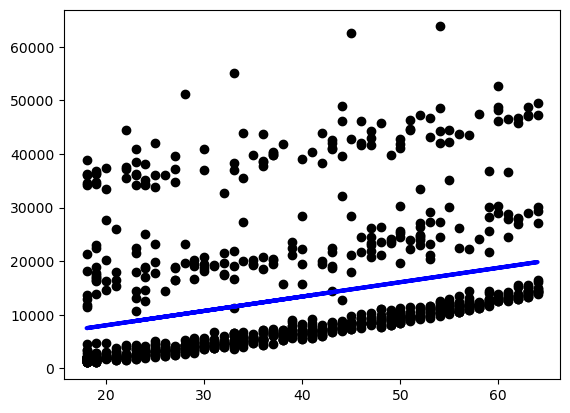

In [11]:
plt.scatter(X_train[:, 0:1], y_train, color='black')
plt.plot(X_test[:, 0:1], y_pred, color='blue', linewidth=3, label='test')
plt.show()

### Multiple Regression

In [12]:
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [13]:
print('Coefficients: \n', reg.coef_)  # coefficients for each column/feature
print('Intercept: \n', reg.intercept_)

Coefficients: 
 [ 2.60023521e+02 -6.20687987e-02  2.89695143e+02  4.72426567e+02
  2.39903237e+04  8.24631478e+02  6.92229126e+01 -1.16771744e+02
 -7.77082646e+02]
Intercept: 
 -11083.79681948463


In [14]:
# Predict using the linear model
y_pred = reg.predict(X_test)

In [15]:
print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.777
MSE: 32345536.749
MAE: 3943.238


### Lasso
Lasso stands for **Least Absolute Shrinkage and Selection Operator**. It shrinks the regression coefficients toward zero by penalizing the regression model with a penalty term called L1-norm, which is the sum of the absolute coefficients. In the case of lasso regression, the penalty has the effect of forcing some of the coefficient estimates, with a minor contribution to the model, to be exactly equal to zero.


In [16]:
reg = Lasso()
reg.fit(X_train, y_train)
print('Coefficients: \n', reg.coef_)
print('Intercept: \n', reg.intercept_)

Coefficients: 
 [  260.02779471     0.           289.49794646   471.79548481
 23983.34349325   932.20355757   177.00996518    -0.
  -660.67566858]
Intercept: 
 -11188.231262807536


In [17]:
y_pred = reg.predict(X_test)
print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.777
MSE: 32343417.104
MAE: 3943.159


### Ridge
Ridge regression shrinks the regression coefficients, so that variables, with minor contribution to the outcome, have their coefficients close to zero. The shrinkage of the coefficients is achieved by penalizing the regression model with a penalty term called L2-norm, which is the sum of the squared coefficients.

Ridge regression shrinks the coefficients towards zero, but it will not set any of them exactly to zero.


In [18]:
reg = Ridge()
reg.fit(X_train, y_train)
print('Coefficients: \n', reg.coef_)
print('Intercept: \n', reg.intercept_)

Coefficients: 
 [ 2.59978002e+02  7.95709475e+00  2.89516470e+02  4.72489810e+02
  2.38257962e+04  8.18652236e+02  6.37741055e+01 -1.06349549e+02
 -7.76076793e+02]
Intercept: 
 -11049.05740705088


In [19]:
y_pred = reg.predict(X_test)
print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.777
MSE: 32317955.448
MAE: 3955.288


## Tabular Dataset for Classification

The dataset [Breast Cancer Wisconsin](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)) is available at the UCI Repository.

The features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei present in the image.

**Attribute Information:**

1) ID number

2) Diagnosis (M = malignant, B = benign)
3-32)

Ten real-valued features are computed for each cell nucleus:

a) radius (mean of distances from center to points on the perimeter)
b) texture (standard deviation of gray-scale values)
c) perimeter
d) area
e) smoothness (local variation in radius lengths)
f) compactness (perimeter^2 / area - 1.0)
g) concavity (severity of concave portions of the contour)
h) concave points (number of concave portions of the contour)
i) symmetry
j) fractal dimension ("coastline approximation" - 1)



In [20]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [21]:
# Load the breast cancer wisconsin dataset.
frame = load_breast_cancer(as_frame=True)
df = frame['data']
X = df.values
y = np.array(frame['target'])

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((398, 30), (171, 30), (398,), (171,))

### Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
clf = LogisticRegression(penalty=None)
clf.fit(X_train, y_train)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(penalty=None)

In [25]:
clf.score(X_test, y_test)

0.9532163742690059

### Lasso (L1 regularization)

In [26]:
clf = LogisticRegression(penalty="l1", solver="liblinear")

In [27]:
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.9649122807017544

In [28]:
from sklearn.linear_model import LogisticRegressionCV

In [29]:
clf = LogisticRegressionCV(penalty="l1", solver="liblinear")
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iter

0.9532163742690059

### Ridge (L2 regularization)

In [30]:
clf = LogisticRegression(penalty="l1", solver="liblinear")
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.9649122807017544

In [31]:
from sklearn.linear_model import RidgeClassifier
clf = RidgeClassifier()
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9590643274853801

In [32]:
from sklearn.linear_model import RidgeClassifierCV
clf = RidgeClassifierCV()
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9415204678362573

### SVM

In [34]:
from sklearn.svm import LinearSVC, SVC
clf = LinearSVC()
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9590643274853801

In [35]:
clf = SVC(kernel="rbf")
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9064327485380117

## Multiclass Classification

In [1]:
from sklearn.datasets import load_iris

In [4]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((105, 4), (45, 4), (105,), (45,))

In [12]:
np.unique(y_train), np.unique(y_test)

(array([0, 1, 2]), array([0, 1, 2]))

### Multinomial Logistic Regression
sklearn natively supports multinomial logistic regression by setting the `multi_class` parameter to "multinomial" in the `LogisticRegression` class.

In [8]:
clf = LogisticRegression(multi_class="multinomial")
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


0.9777777777777777

### OVR Logistic Regression
sklearn also supports ovr logistic regression

In [9]:
clf = LogisticRegression(multi_class="ovr")
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


0.9555555555555556

### OVO Logistic Regression
ovo is not natively supported, but it can be implemented using the OneVsOneClassifier wrapper from sklearn.multiclass

In [10]:
from sklearn.multiclass import OneVsRestClassifier

In [11]:
clf = OneVsRestClassifier(LogisticRegression())
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9555555555555556

### SVM
(ovr is the default for SVC)

In [36]:
clf = SVC(kernel="linear")
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9532163742690059

## Sequential Dataset for Classification via Feature Extraction


**Promoter or Not? Bioinformatics Dataset**
This dataset addresses a binary classification problem: determining whether a DNA sequence corresponds to a promoter region.

Promoter regions are located near transcription start sites and regulate gene expression by controlling the binding of RNA polymerase. Accurate identification of promoters is therefore a central task in bioinformatics and gene regulation analysis.


In [121]:
df = pd.read_csv("./Data/promoter_nonpromoter.csv")
df.head()

,sequence,label
0,CTGTCCAATCATAAGCCTCACGTGACCTGCCGCGTAGGGAGGGCAC...,1
1,CCTTATTATACCTGTAAACTATTCTCTTCCTTTGTTACTTGCTTTT...,1
2,TTTGCCACACTGCAGCATTAGGATGGGACTTCTCTTCCTGTTCCTG...,1
3,ACAAATAACAAAGATAGTTTTAGTAGATTATATCTGGGCTGTAGTG...,1
4,GAGGAGAAATTGGAGACAACCTCCTCCCACAATCCTCCGCGGCTCA...,1


In [122]:
df.shape

(60000, 2)

### Simple Feature Extraction from DNA Sequences

We convert each nucleotide sequence into a small set of numerical features so that standard machine learning models can process them. Since models such as logistic regression or random forests require fixed-length numeric input, we summarize each sequence using biologically meaningful statistics.

For each sequence, we compute:

* **Length**: Total number of nucleotides.
* **GC fraction**: Proportion of G and C bases. This often relates to structural stability and regulatory properties.
* **AT fraction**: Proportion of A and T bases.
* **Shannon entropy**: Measures base diversity. Higher entropy indicates more uniform nucleotide distribution, lower entropy suggests bias or repetitive structure.
* **Maximum homopolymer run**: Length of the longest stretch of identical consecutive bases, capturing repetitiveness.

The result is a fixed-size feature vector of five values per sequence. This provides a simple, interpretable baseline representation that can be directly used in conventional machine learning pipelines.


In [123]:
import numpy as np
import math

def simple_seq_features(sequences):
    features = []

    for seq in sequences:
        seq = (seq or "").upper()
        seq = "".join(b for b in seq if b in "ACGT")

        L = len(seq)
        if L == 0:
            features.append([0, 0, 0, 0, 0])
            continue

        # Base frequencies
        a = seq.count("A") / L
        c = seq.count("C") / L
        g = seq.count("G") / L
        t = seq.count("T") / L

        gc = g + c
        at = a + t

        # Shannon entropy
        entropy = 0
        for p in [a, c, g, t]:
            if p > 0:
                entropy -= p * math.log2(p)

        # Max homopolymer run
        max_run = 1
        current = 1
        for i in range(1, L):
            if seq[i] == seq[i - 1]:
                current += 1
                max_run = max(max_run, current)
            else:
                current = 1

        features.append([L, gc, at, entropy, max_run])

    return np.array(features)

In [124]:
# convert sequences to features
X = simple_seq_features(df["sequence"])
y = df["label"].values

### Classification

In [130]:
# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((42000, 5), (18000, 5), (42000,), (18000,))

In [128]:
# Linear model
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(penalty=None)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9998333333333334

In [129]:
# Ridge classifier CV
from sklearn.linear_model import RidgeClassifierCV
clf = RidgeClassifierCV()
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9997777777777778

## Image Dataset for Classification via Feature Extraction

UCI ML hand-written digits datasets https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits


In [14]:
from sklearn.datasets import load_digits

In [33]:
digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [ ]:
X = digits.images
y = digits.target

X.shape, y.shape

((1797, 8, 8), (1797,))

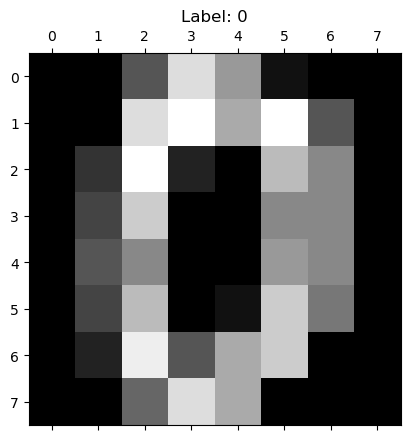

In [23]:
import matplotlib.pyplot as plt
plt.matshow(X[0], cmap="gray")
plt.title(f"Label: {y[0]}")
plt.show()

In [26]:
def extract_stat_features(images):
    features = []
    for img in images:
        features.append([
            np.mean(img),  # mean pixel value
            np.std(img),  # std pixel value
            np.sum(img > 0),  # number of non-zero pixels
            np.min(img),  # min pixel value
            np.max(img)  # max pixel value
        ])
    return np.array(features)

In [27]:
X_features = extract_stat_features(X)
X_features.shape

(1797, 5)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.3, random_state=100)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1257, 5), (540, 5), (1257,), (540,))

In [30]:
clf = LogisticRegression()
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.23703703703703705

In [ ]:
# the score above is not great, but it's better than random guessing (which would be around 0.1 for 10 classes)

from sklearn.dummy import DummyClassifier

clf = DummyClassifier(strategy="most_frequent")
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

In [41]:
# in this very simple dataset, we can get a very good score even with a linear model on the raw pixel values, without any feature extraction

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

clf = LogisticRegression()
clf.fit(X_train.reshape(X_train.shape[0], -1), y_train)
clf.score(X_test.reshape(X_test.shape[0], -1), y_test)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.975925925925926

# Exercise
Solve the predictive task on the `wine` dataset. 
- use the correct type of model (Regressor or Classifier?)
- find the best-performing model

In [38]:
from sklearn.datasets import load_wine
X, y = load_wine(return_X_y=True)